Step-1 --> Firstly we need to connect to database file(.db) ,If we dont have  file then we need to create databas file, Once conectectopn is established it will return us the Object , 
Now in any databases when we connect with python, we create something called as cursor,Cursor is abject from the connection which can execute sql queries

Step-2 --> Connect DB Connection with Person Object,

# Connecting Python with SQLite Database

## Step 1: Connect to the Database

First, we need to **connect Python to the database**.

For SQLite, the database is usually stored in a `.db` file.

Example:

```text
company.db
```

We use Python's built-in `sqlite3` module:

```python
import sqlite3

connection = sqlite3.connect("company.db")
```

### What happens here?

```text
sqlite3.connect("company.db")
            ↓
      Database Connection
            ↓
       Connection Object
```

- If `company.db` **already exists**, Python connects to it.
- If `company.db` **does not exist**, SQLite creates a new database file.
- `sqlite3.connect()` returns a **Connection Object**.

We store this object in a variable:

```python
connection = sqlite3.connect("company.db")
```

Here:

```text
connection → Connection Object
```

---

# Step 2: Create a Cursor

After establishing a connection, we create a **Cursor Object**.

```python
cursor = connection.cursor()
```

The cursor is created from the connection object:

```text
Connection Object
       |
       | .cursor()
       ↓
Cursor Object
```

## What is a Cursor?

A **Cursor** is an object used to **execute SQL queries** and retrieve results from the database.

For example:

```python
cursor.execute("SELECT * FROM Employee")
```

Here:

```text
cursor
   ↓
execute()
   ↓
SQL Query
   ↓
Database
```

---

# Complete Flow

The basic process of working with SQLite using Python is:

```text
Python
   ↓
sqlite3
   ↓
Connect to Database
   ↓
Connection Object
   ↓
Create Cursor
   ↓
Cursor Object
   ↓
Execute SQL Query
   ↓
Database
   ↓
Get Result
```

---

# Example

```python
import sqlite3

# Step 1: Connect to database
connection = sqlite3.connect("company.db")

# Step 2: Create cursor
cursor = connection.cursor()

# Step 3: Execute SQL query
cursor.execute("""
CREATE TABLE IF NOT EXISTS Employee (
    id INTEGER PRIMARY KEY,
    name TEXT,
    salary INTEGER
)
""")

# Step 4: Save changes
connection.commit()

# Step 5: Close connection
connection.close()
```

---

# Important Terms

| Term | Meaning |
|---|---|
| `sqlite3` | Python's built-in module for SQLite |
| `connect()` | Establishes a connection with the database |
| Connection Object | Represents the connection to the database |
| `cursor()` | Creates a cursor object |
| Cursor Object | Used to execute SQL queries |
| `execute()` | Executes an SQL query |
| `commit()` | Saves changes to the database |
| `close()` | Closes the database connection |

---

# Interview Question ⭐

## Q: What is a Cursor in Python Database Programming?

### Answer

> A Cursor is an object created from a database connection that is used to execute SQL queries and retrieve results from the database.

### Example

```python
connection = sqlite3.connect("company.db")

cursor = connection.cursor()

cursor.execute("SELECT * FROM Employee")
```

Here:

```text
connection
     ↓
   cursor()
     ↓
cursor
     ↓
execute()
     ↓
SQL Query
```

---

# Easy Way to Remember

```text
Connection → Connect to Database

Cursor → Execute SQL Queries

Commit → Save Changes

Close → Close Connection
```

In [ ]:
import sqlite3

# step-1
conn = sqlite3.connect('mydatabase.db')
#Step-2
c = conn.cursor()
#Step-3
c.execute('PRAGMA foreign_keys = ON;') #Enable foreign keys to database


In [ ]:
#Create table
c.execute(''' Create Table UltimateDataScience(
student_id INTEGER PRIMARY KEY NOT NULL,
name TEXT NOT NULL,
batch_id TEXT NOT NULL

)''')



In [18]:
# Insert data into table
student_data = [
    (1, 'John Doe', 'Batch A'),
    (2, 'Jane Smith', 'Batch B'),
    (3, 'Alice Johnson', 'Batch A'),
    (4, 'Bob Brown', 'Batch C')
]

#c.execute('''INSERT INTO UltimateDataScience(student_id, name, batch_id) VALUES(?, ?, ?)''', student_data[0])
#c.execute("DELETE FROM UltimateDataScience") #
#conn.commit()'''
c.executemany('''INSERT INTO UltimateDataScience(student_id, name, batch_id) VALUES(?, ?, ?)''', student_data)
#Push The Dta from memory to the database
conn.commit()


    

# Using `c.execute()` to Insert Data into SQLite

The following code is used to **insert data into an SQLite database table using a parameterized SQL query**:

```python
c.execute(
    '''INSERT INTO UltimateDataScience(student_id, name, batch_id)
       VALUES(?, ?, ?)''',
    student_data[0]
)
```

---

# 1. `c.execute()`

```python
c.execute(...)
```

Here, `c` is the **Cursor Object**.

The `execute()` method is used to execute an SQL query.

```text
Connection
    ↓
  Cursor
    ↓
execute()
    ↓
SQL Query
```

---

# 2. `INSERT INTO`

```sql
INSERT INTO UltimateDataScience
```

This tells the database:

> Insert a new row into the `UltimateDataScience` table.

---

# 3. Column Names

```sql
(student_id, name, batch_id)
```

These are the columns where we want to insert the data.

For example:

```text
student_id → 101
name       → Shubham
batch_id   → 5
```

---

# 4. `VALUES(?, ?, ?)`

```sql
VALUES(?, ?, ?)
```

The `?` symbols are **placeholders**.

They represent values that will be provided separately.

For example:

```python
student_data[0]
```

might contain:

```python
(101, "Shubham", 5)
```

Then SQLite effectively executes:

```sql
INSERT INTO UltimateDataScience
(student_id, name, batch_id)
VALUES
(101, 'Shubham', 5);
```

---

# Why Do We Use `?`?

The `?` placeholders are used for **parameterized queries**.

Instead of doing this:

```python
query = f"""
INSERT INTO UltimateDataScience
(student_id, name, batch_id)
VALUES ({student_id}, '{name}', {batch_id})
"""
```

we use:

```python
c.execute(
    """
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    """,
    (student_id, name, batch_id)
)
```

## Advantages

- Safer
- Helps prevent **SQL Injection**
- Handles values correctly
- Separates SQL code from data

---

# 5. What is `student_data[0]`?

Suppose:

```python
student_data = [
    (101, "Shubham", 5),
    (102, "Rahul", 6),
    (103, "Amit", 5)
]
```

Then:

```python
student_data[0]
```

returns:

```python
(101, "Shubham", 5)
```

These values are mapped to the `?` placeholders **in order**:

```text
?        → 101
?        → Shubham
?        → 5
```

Therefore:

```python
c.execute(
    '''
    INSERT INTO UltimateDataScience(student_id, name, batch_id)
    VALUES(?, ?, ?)
    ''',
    student_data[0]
)
```

means:

```text
student_data[0]
       ↓
(101, "Shubham", 5)
       ↓
    ?    ?    ?
    ↓    ↓    ↓
   101 Shubham 5
       ↓
INSERT INTO TABLE
```

---

# Complete Example

```python
import sqlite3

connection = sqlite3.connect("college.db")

c = connection.cursor()

student_data = [
    (101, "Shubham", 5),
    (102, "Rahul", 6),
    (103, "Amit", 5)
]

c.execute("""
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
""", student_data[0])

connection.commit()

connection.close()
```

This inserts:

```text
101 | Shubham | 5
```

into the table.

---

# If You Want to Insert Multiple Rows

If `student_data` contains multiple tuples, use `executemany()`:

```python
c.executemany("""
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
""", student_data)
```

This inserts:

```text
101 | Shubham | 5
102 | Rahul   | 6
103 | Amit    | 5
```

---

# `execute()` vs `executemany()`

| Method | Purpose |
|---|---|
| `execute()` | Execute a query once |
| `executemany()` | Execute the same query for multiple sets of values |

### `execute()`

```python
c.execute(query, student_data[0])
```

Inserts **one row**.

### `executemany()`

```python
c.executemany(query, student_data)
```

Inserts **multiple rows**.

---

# Interview Question ⭐

## Q: Why are `?` used in SQLite queries?

### Answer

> `?` is a parameter placeholder used in parameterized SQL queries. It allows us to pass values separately from the SQL statement, improving security and helping prevent SQL injection.

---

# Important Concept

```text
c.execute()
    ↓
Execute SQL Query

? ? ?
 ↓ ↓ ↓
Placeholders

student_data[0]
    ↓
Actual Values
```

---

# Easy Way to Remember

```text
c.execute(SQL_QUERY, VALUES)
             ↓       ↓
           Query   Data
```

Example:

```python
c.execute(
    "INSERT INTO Student VALUES (?, ?, ?)",
    (101, "Shubham", 5)
)
```

```text
SQL Query
    +
Actual Values
    ↓
Database
```

---

# One-Line Interview Definition

> **`execute()` executes an SQL statement, while `?` placeholders allow values to be passed separately as parameters, making the query safer and easier to work with.**

=============================================================================================================================================

# `executemany()` in Python SQLite

`executemany()` is used when we want to **execute the same SQL query multiple times with different sets of values**.

It is especially useful for:

- Inserting multiple rows
- Updating multiple rows
- Deleting multiple rows

---

# Syntax

```python
cursor.executemany(SQL_QUERY, DATA)
```

Where:

- `cursor` → Cursor object
- `SQL_QUERY` → SQL query containing placeholders (`?`)
- `DATA` → Collection of values, usually a list of tuples

---

# Example: Insert Multiple Rows

Suppose we have:

```python
student_data = [
    (1, 'John Doe', 'Batch A'),
    (2, 'Jane Smith', 'Batch B'),
    (3, 'Alice Johnson', 'Batch A'),
    (4, 'Bob Brown', 'Batch C')
]
```

We can insert all these rows using:

```python
c.executemany(
    '''
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    ''',
    student_data
)

connection.commit()
```

---

# How `executemany()` Works

The query is:

```sql
INSERT INTO UltimateDataScience
(student_id, name, batch_id)
VALUES (?, ?, ?)
```

And the data is:

```python
student_data = [
    (1, 'John Doe', 'Batch A'),
    (2, 'Jane Smith', 'Batch B'),
    (3, 'Alice Johnson', 'Batch A'),
    (4, 'Bob Brown', 'Batch C')
]
```

Conceptually, `executemany()` applies the query to each tuple:

```text
Query
  +
(1, 'John Doe', 'Batch A')
       ↓
    INSERT

Query
  +
(2, 'Jane Smith', 'Batch B')
       ↓
    INSERT

Query
  +
(3, 'Alice Johnson', 'Batch A')
       ↓
    INSERT

Query
  +
(4, 'Bob Brown', 'Batch C')
       ↓
    INSERT
```

So four rows are inserted.

---

# `execute()` vs `executemany()`

This is an important interview question.

## `execute()`

Used to execute a query **once**.

```python
c.execute(
    '''
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    ''',
    (1, 'John Doe', 'Batch A')
)
```

This inserts **one row**.

---

## `executemany()`

Used to execute the **same query multiple times** with different values.

```python
c.executemany(
    '''
    INSERT INTO UltimateDataScience
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    ''',
    student_data
)
```

This can insert **multiple rows**.

---

# Simple Comparison

| Method | Usage |
|---|---|
| `execute()` | Execute query once |
| `executemany()` | Execute same query multiple times |
| `fetchone()` | Retrieve one row |
| `fetchall()` | Retrieve all rows |

---

# `executemany()` with UPDATE

`executemany()` is not limited to `INSERT`.

For example:

```python
updates = [
    (60000, 1),
    (70000, 2),
    (80000, 3)
]

c.executemany(
    '''
    UPDATE Employee
    SET salary = ?
    WHERE employee_id = ?
    ''',
    updates
)

connection.commit()
```

Conceptually:

```text
employee_id 1 → salary = 60000
employee_id 2 → salary = 70000
employee_id 3 → salary = 80000
```

---

# `executemany()` with DELETE

It can also be used to delete multiple specific rows:

```python
student_ids = [
    (1,),
    (3,),
    (4,)
]

c.executemany(
    '''
    DELETE FROM UltimateDataScience
    WHERE student_id = ?
    ''',
    student_ids
)

connection.commit()
```

This deletes students:

```text
1
3
4
```

---

# Why Use `executemany()`?

## 1. Avoid Repeating Code

Instead of:

```python
c.execute(query, data[0])
c.execute(query, data[1])
c.execute(query, data[2])
c.execute(query, data[3])
```

we can simply use:

```python
c.executemany(query, data)
```

---

## 2. Convenient for Bulk Operations

It is useful when working with many rows.

---

## 3. Uses Parameterized Queries

The values are passed separately:

```python
VALUES (?, ?, ?)
```

This is safer than constructing SQL strings manually.

---

# Interview Question ⭐

## Q: What is the use of `executemany()`?

### Answer

> `executemany()` is used to execute the same SQL statement multiple times with different sets of parameter values. It is commonly used for bulk insert, update, or delete operations.

### Example

```python
c.executemany(
    '''
    INSERT INTO Student
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    ''',
    student_data
)
```

---

# Important Interview Point ⭐

`executemany()` does **not** mean:

> Execute many different SQL queries.

It means:

> **Execute the same SQL statement repeatedly using multiple parameter sets.**

---

# Easy Way to Remember

```text
execute()
    ↓
One Query + One Set of Values

executemany()
    ↓
One Query + Multiple Sets of Values
```

### Example

```python
# One row
c.execute(query, (1, "John", "Batch A"))

# Multiple rows
c.executemany(query, student_data)
```

---

# Quick Revision

```text
execute()
    ↓
Single execution

executemany()
    ↓
Multiple executions
    ↓
Same SQL statement
    ↓
Different parameter values
```

> **`execute()` → One set of values**

> **`executemany()` → Multiple sets of values**

========================================================================================================================================

# `commit()` and `close()` in Python SQLite

When working with SQLite in Python, two important methods are:

- `connection.commit()`
- `connection.close()`

They perform **different tasks**.

---

# 1. `connection.commit()`

`commit()` is used to **save the changes made to the database**.

### Syntax

```python
connection.commit()
```

When we perform operations such as:

- `INSERT`
- `UPDATE`
- `DELETE`

the changes are part of the current transaction. We use `commit()` to save those changes.

### Example

```python
c.execute(
    """
    INSERT INTO Student
    (student_id, name)
    VALUES (?, ?)
    """,
    (101, "Shubham")
)

connection.commit()
```

Here:

```text
c.execute()
     ↓
Perform INSERT
     ↓
connection.commit()
     ↓
Save the change
```

---

# 2. `connection.close()`

`close()` is used to **close the database connection** after we have finished working with the database.

### Syntax

```python
connection.close()
```

It releases the resources associated with the database connection.

### Example

```python
connection.close()
```

After closing the connection, we cannot normally execute more SQL queries using that connection.

---

# 3. Difference Between `commit()` and `close()`

| Method | Purpose |
|---|---|
| `commit()` | Save database changes |
| `rollback()` | Undo uncommitted changes |
| `close()` | Close the database connection |

### Easy Way to Remember

```text
COMMIT
  ↓
SAVE CHANGES

ROLLBACK
  ↓
UNDO CHANGES

CLOSE
  ↓
CLOSE CONNECTION
```

---

# 4. Correct Order

When performing database operations, a common sequence is:

```python
c.execute(...)
connection.commit()
connection.close()
```

The complete flow is:

```text
SQL Operation
      ↓
   commit()
      ↓
 Save Changes
      ↓
   close()
      ↓
Close Connection
```

---

# 5. Complete Example

```python
import sqlite3

# 1. Connect to database
connection = sqlite3.connect("college.db")

# 2. Create cursor
c = connection.cursor()

# 3. Execute SQL query
c.execute(
    """
    INSERT INTO Student
    (student_id, name)
    VALUES (?, ?)
    """,
    (101, "Shubham")
)

# 4. Save the changes
connection.commit()

# 5. Close the connection
connection.close()
```

---

# 6. Why is `commit()` Important?

Suppose we execute:

```python
c.execute(
    """
    INSERT INTO Student
    (student_id, name)
    VALUES (?, ?)
    """,
    (101, "Shubham")
)
```

The database operation has been performed, but we should commit the transaction:

```python
connection.commit()
```

This saves the change.

### Flow

```text
INSERT
  ↓
Transaction
  ↓
COMMIT
  ↓
Changes Saved
```

---

# 7. Why is `close()` Important?

A database connection uses system resources.

After finishing the database operations:

```python
connection.close()
```

closes the connection and releases those resources.

### Flow

```text
Database Connection
       ↓
Perform Operations
       ↓
Finish Work
       ↓
connection.close()
       ↓
Resources Released
```

---

# 8. What Happens If We Don't Use `commit()`?

Suppose:

```python
c.execute(
    "INSERT INTO Student VALUES (?, ?)",
    (101, "Shubham")
)

connection.close()
```

If the transaction was not committed, the change may not be persisted.

Therefore, for database operations that modify data, use:

```python
connection.commit()
```

before closing the connection.

---

# 9. What Happens If We Don't Use `close()`?

If we don't close the connection, it can remain open unnecessarily and continue consuming resources.

Therefore, after finishing database operations, it is good practice to close the connection:

```python
connection.close()
```

---

# 10. `commit()` with `executemany()`

When using `executemany()` to insert multiple rows:

```python
student_data = [
    (1, "John", "Batch A"),
    (2, "Jane", "Batch B"),
    (3, "Alice", "Batch A")
]

c.executemany(
    """
    INSERT INTO Student
    (student_id, name, batch_id)
    VALUES (?, ?, ?)
    """,
    student_data
)

connection.commit()
connection.close()
```

The flow is:

```text
student_data
     ↓
executemany()
     ↓
Multiple INSERT operations
     ↓
commit()
     ↓
Save Changes
     ↓
close()
     ↓
Close Connection
```

---

# 11. `commit()` vs `rollback()`

These are both related to **transactions**.

## `commit()`

Saves the changes:

```python
connection.commit()
```

## `rollback()`

Cancels the uncommitted changes:

```python
connection.rollback()
```

### Example

```text
Transaction
     │
     ├── SQL Operations
     │
     ├── Everything OK
     │       ↓
     │    COMMIT
     │       ↓
     │    SAVE
     │
     └── Something went wrong
             ↓
          ROLLBACK
             ↓
           UNDO
```

---

# 12. Real-World Example

Imagine transferring ₹10,000 from Account A to Account B.

There are two operations:

```sql
UPDATE Account
SET balance = balance - 10000
WHERE account_id = 1;
```

and:

```sql
UPDATE Account
SET balance = balance + 10000
WHERE account_id = 2;
```

If both operations are successful:

```python
connection.commit()
```

saves both changes.

If something goes wrong before the transaction is committed:

```python
connection.rollback()
```

can undo the uncommitted changes.

After finishing:

```python
connection.close()
```

closes the database connection.

---

# 13. Important Interview Questions ⭐

## Q1. What is `commit()` in SQL?

### Answer

> `COMMIT` is a transaction control operation used to permanently save the changes made during a transaction.

---

## Q2. Why do we use `connection.commit()` in Python SQLite?

### Answer

> `connection.commit()` saves the changes made by operations such as `INSERT`, `UPDATE`, and `DELETE` to the SQLite database.

---

## Q3. What is the purpose of `connection.close()`?

### Answer

> `connection.close()` closes the database connection and releases the resources associated with that connection.

---

## Q4. What is the difference between `commit()` and `close()`?

### Answer

> `commit()` saves the database changes, whereas `close()` closes the database connection.

---

## Q5. What is the difference between `commit()` and `rollback()`?

### Answer

> `commit()` saves the transaction changes, while `rollback()` cancels the uncommitted changes.

---

## Q6. Does `SELECT` require `commit()`?

### Answer

> Normally, no. `SELECT` is a read operation and does not modify the database.

---

# 14. Quick Revision

```text
CONNECT
   ↓
CURSOR
   ↓
EXECUTE / EXECUTEMANY
   ↓
COMMIT
   ↓
SAVE CHANGES
   ↓
CLOSE
   ↓
CLOSE DATABASE CONNECTION
```

### Remember

```text
execute()       → Execute SQL
executemany()   → Execute SQL for multiple parameter sets
commit()        → Save changes
rollback()      → Undo uncommitted changes
close()         → Close connection
```

---

# One-Line Interview Definitions

> **`commit()` → Saves the changes made during a database transaction.**

> **`rollback()` → Undoes uncommitted changes made during a transaction.**

> **`close()` → Closes the database connection and releases its resources.**

### Complete Pattern

```python
c.execute(...)
connection.commit()
connection.close()
```

For multiple rows:

```python
c.executemany(...)
connection.commit()
connection.close()
```

System Design Question


-system 2 ggb ram 100 gb storage e have a csv file 5 milloions of records whose size is 8 gb now i want all of these to be stored in mmy DB this is dydtem design tel me solution

Open CSV
   ↓
Read one line at a time
   ↓
Insert into DB
   ↓
Commit every 100 rows
   ↓
Continue
   ↓
Close connection

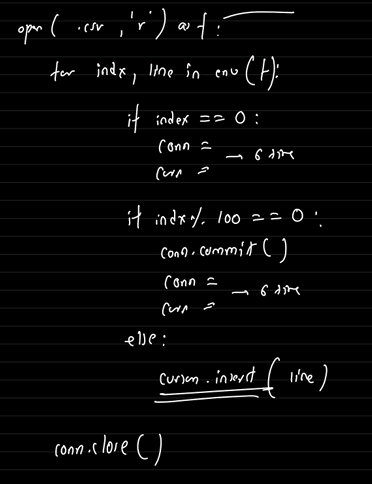